Step 1: Load and Preview the Data

In [1]:
import pandas as pd

# Load the dataset
csv_file_path = 'XSS_Dataset.csv'  # Ensure this path is correct
df = pd.read_csv(csv_file_path)

# Display basic information about the dataset
print(df.info())  # Structure and types of columns
print(df.head())  # First few rows
print(df.describe())  # Summary statistics for numeric columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13686 entries, 0 to 13685
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  13686 non-null  int64 
 1   Sentence    13686 non-null  object
 2   Label       13686 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 320.9+ KB
None
   Unnamed: 0                                           Sentence  Label
0           0  <li><a href="/wiki/File:Socrates.png" class="i...      0
1           1               <tt onmouseover="alert(1)">test</tt>      1
2           2  \t </span> <span class="reference-text">Steeri...      0
3           3  \t </span> <span class="reference-text"><cite ...      0
4           4  \t </span>. <a href="/wiki/Digital_object_iden...      0
         Unnamed: 0         Label
count  13686.000000  13686.000000
mean    6842.500000      0.538726
std     3950.952227      0.498516
min        0.000000      0.000000
25%     3421.250000      0.000000

Step 2: Check for Missing or Duplicate Data

In [2]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate entries
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove duplicate rows
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {len(df)}")



Unnamed: 0    0
Sentence      0
Label         0
dtype: int64
Number of duplicate rows: 0
Number of rows after removing duplicates: 13686


In [3]:
print(df.info())  # Structure and types of columns
print(df.head())  # First few rows
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13686 entries, 0 to 13685
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  13686 non-null  int64 
 1   Sentence    13686 non-null  object
 2   Label       13686 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 320.9+ KB
None
   Unnamed: 0                                           Sentence  Label
0           0  <li><a href="/wiki/File:Socrates.png" class="i...      0
1           1               <tt onmouseover="alert(1)">test</tt>      1
2           2  \t </span> <span class="reference-text">Steeri...      0
3           3  \t </span> <span class="reference-text"><cite ...      0
4           4  \t </span>. <a href="/wiki/Digital_object_iden...      0
         Unnamed: 0         Label
count  13686.000000  13686.000000
mean    6842.500000      0.538726
std     3950.952227      0.498516
min        0.000000      0.000000
25%     3421.250000      0.000000

Step 3: Analyze the Distribution of Labels

Label
1    7373
0    6313
Name: count, dtype: int64


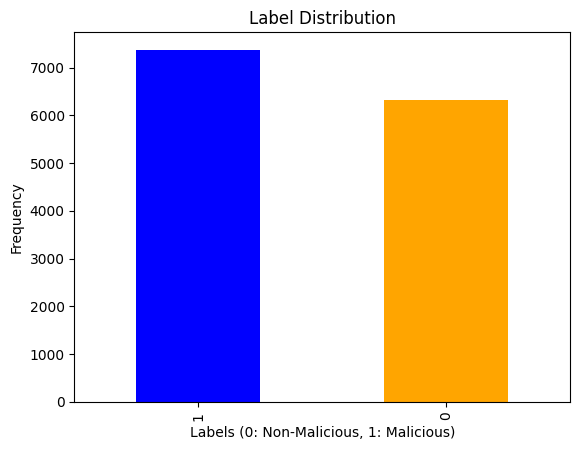

In [4]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = df['Label'].value_counts()
print(label_counts)

# Visualize the distribution
label_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Label Distribution')
plt.xlabel('Labels (0: Non-Malicious, 1: Malicious)')
plt.ylabel('Frequency')
plt.show()


Step 3.5: Undersampling the Majority Class

In [6]:
# Separate the classes
majority_class = df[df['Label'] == 1]
minority_class = df[df['Label'] == 0]

# Downsample the majority class
majority_downsampled = majority_class.sample(n=len(minority_class), random_state=42)

# Combine the minority class with the downsampled majority class
balanced_df = pd.concat([majority_downsampled, minority_class])

# Shuffle the dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the new label distribution
print(balanced_df['Label'].value_counts())

Label
0    6313
1    6313
Name: count, dtype: int64


Label
0    6313
1    6313
Name: count, dtype: int64


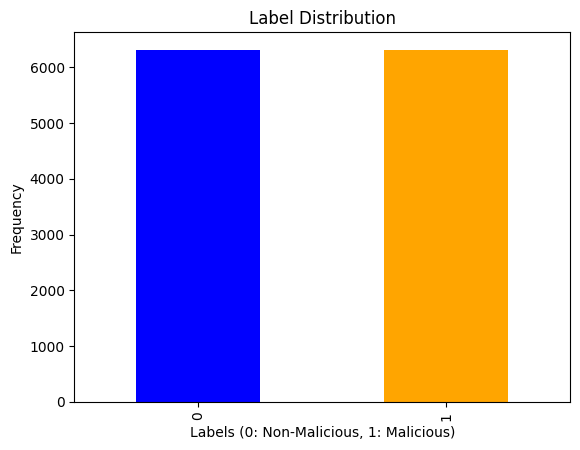

In [8]:
label_counts = balanced_df['Label'].value_counts()
print(label_counts)
label_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Label Distribution')
plt.xlabel('Labels (0: Non-Malicious, 1: Malicious)')
plt.ylabel('Frequency')
plt.show()

Step 4: Analyze Payload Characteristics
1. Length of Payloads: Examine the length of XSS queries.

count    12626.000000
mean       112.424362
std        215.411335
min          1.000000
25%         40.000000
50%         58.000000
75%         99.000000
max       5911.000000
Name: Payload_Length, dtype: float64


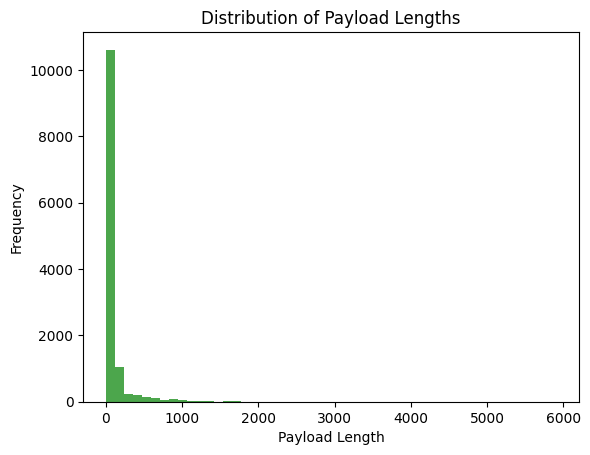

In [11]:
balanced_df['Payload_Length'] = balanced_df['Sentence'].apply(len)

# Basic statistics
print(balanced_df['Payload_Length'].describe())

# Visualize the distribution
balanced_df['Payload_Length'].plot(kind='hist', bins=50, color='green', alpha=0.7)
plt.title('Distribution of Payload Lengths')
plt.xlabel('Payload Length')
plt.ylabel('Frequency')
plt.show()


2. Common Words or Tokens: Identify frequent XSS keywords.

In [12]:
from collections import Counter
import re

# Tokenize and count words
all_words = ' '.join(balanced_df['Sentence']).lower()
words = re.findall(r'\b\w+\b', all_words)
common_words = Counter(words).most_common(20)

# Display top 20 words
print("Most Common Words:", common_words)


Most Common Words: [('a', 10965), ('1', 7793), ('alert', 6208), ('href', 5411), ('class', 4684), ('li', 4631), ('span', 4265), ('amp', 3549), ('title', 3524), ('style', 3500), ('test', 2924), ('id', 2805), ('wiki', 2762), ('x', 2222), ('rft', 2144), ('mw', 1686), ('contenteditable', 1549), ('the', 1413), ('div', 1340), ('b', 1304)]


Step 5: Analyze Malicious vs. Non-Malicious Queries
Compare properties (e.g., length, keywords) of malicious and non-malicious queries.

Malicious Payload Length Statistics:
count    6313.000000
mean       62.203548
std        32.571607
min         5.000000
25%        42.000000
50%        52.000000
75%        65.000000
max       425.000000
Name: Payload_Length, dtype: float64

Non-Malicious Payload Length Statistics:
count    6313.000000
mean      162.645177
std       294.457924
min         1.000000
25%        20.000000
50%        89.000000
75%       123.000000
max      5911.000000
Name: Payload_Length, dtype: float64


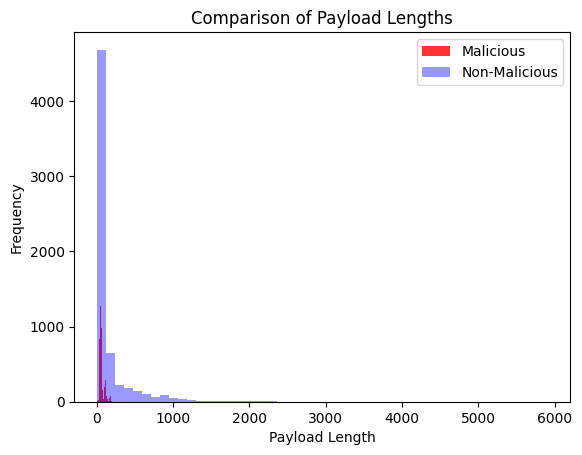

In [15]:
malicious = balanced_df[balanced_df['Label'] == 1]
non_malicious = balanced_df[balanced_df['Label'] == 0]

# Compare lengths
print("Malicious Payload Length Statistics:")
print(malicious['Payload_Length'].describe())

print("\nNon-Malicious Payload Length Statistics:")
print(non_malicious['Payload_Length'].describe())

# Visualize
malicious['Payload_Length'].plot(kind='hist', bins=50, color='red', alpha=0.8, label='Malicious')
non_malicious['Payload_Length'].plot(kind='hist', bins=50, color='blue', alpha=0.4, label='Non-Malicious')
plt.title('Comparison of Payload Lengths')
plt.xlabel('Payload Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Step 6: Tokenize and Analyze Inputs
Inspect the tokenized inputs for trends or anomalies:

In [16]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize the first few queries
for i in range(5):
    tokens = tokenizer(balanced_df['Sentence'][i])['input_ids']
    print(f"Sentence {i+1}: {balanced_df['Sentence'][i]}")
    print(f"Tokenized Input IDs: {tokens}\n")


f:\Anaconda\envs\my_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sentence 1:  </li>
Tokenized Input IDs: [101, 1026, 1013, 5622, 1028, 102]

Sentence 2: <ul><li><a href="/wiki/Database" title="Database">Database management system </a> </li>
Tokenized Input IDs: [101, 1026, 17359, 1028, 1026, 5622, 1028, 1026, 1037, 17850, 12879, 1027, 1000, 1013, 15536, 3211, 1013, 7809, 1000, 2516, 1027, 1000, 7809, 1000, 1028, 7809, 2968, 2291, 1026, 1013, 1037, 1028, 1026, 1013, 5622, 1028, 102]

Sentence 3: <i onpointerenter=alert(1)>XSS</i>
Tokenized Input IDs: [101, 1026, 1045, 2006, 8400, 7869, 10111, 2099, 1027, 9499, 1006, 1015, 1007, 1028, 1060, 4757, 1026, 1013, 1045, 1028, 102]

Sentence 4: <input2 onpointerup=alert(1)>XSS</input2>
Tokenized Input IDs: [101, 1026, 7953, 2475, 2006, 8400, 2121, 6279, 1027, 9499, 1006, 1015, 1007, 1028, 1060, 4757, 1026, 1013, 7953, 2475, 1028, 102]

Sentence 5: <a href="/wiki/K-nearest_neighbor_algorithm" class="mw-redirect" title="K-nearest neighbor algorithm">K-nearest neighbor algorithm </a>:
Tokenized Input IDs: [101,

Correlation Matrix: For numerical features.
Word Clouds: For visualizing common words in payloads.

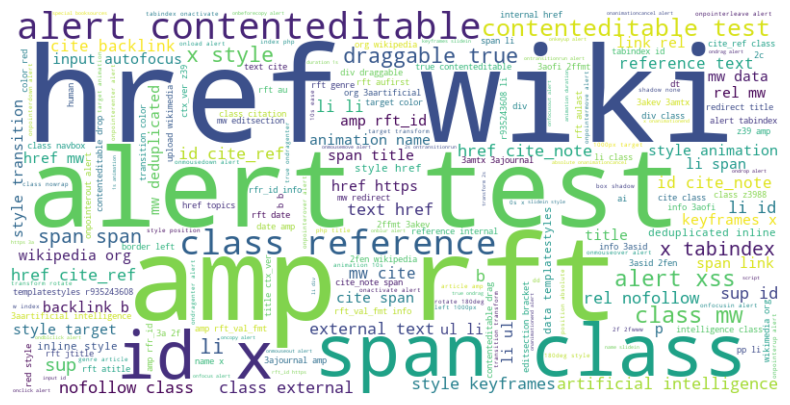

In [17]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [18]:
print(balanced_df.info())  # Structure and types of columns
print(balanced_df.head())  # First few rows
print(balanced_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12626 entries, 0 to 12625
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      12626 non-null  int64 
 1   Sentence        12626 non-null  object
 2   Label           12626 non-null  int64 
 3   Payload_Length  12626 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 394.7+ KB
None
   Unnamed: 0                                           Sentence  Label  \
0        1638                                              </li>      0   
1        1237  <ul><li><a href="/wiki/Database" title="Databa...      0   
2        3641                 <i onpointerenter=alert(1)>XSS</i>      1   
3       12585          <input2 onpointerup=alert(1)>XSS</input2>      1   
4        2432  <a href="/wiki/K-nearest_neighbor_algorithm" c...      0   

   Payload_Length  
0               6  
1              87  
2              34  
3              41  
4             136  


In [21]:
df = balanced_df 

df.drop(columns=['Payload_Length'], inplace=True)

print(df.head())


   Unnamed: 0                                           Sentence  Label
0        1638                                              </li>      0
1        1237  <ul><li><a href="/wiki/Database" title="Databa...      0
2        3641                 <i onpointerenter=alert(1)>XSS</i>      1
3       12585          <input2 onpointerup=alert(1)>XSS</input2>      1
4        2432  <a href="/wiki/K-nearest_neighbor_algorithm" c...      0


Saving balanced_df

In [22]:
# Save the balanced dataset to a new CSV file
balanced_df.to_csv("balanced_XSS_dataset.csv", index=False)

print("Balanced dataset saved as 'balanced_XSS_dataset.csv'")


Balanced dataset saved as 'balanced_XSS_dataset.csv'


In [23]:
loaded_df = pd.read_csv("balanced_XSS_dataset.csv")
print(loaded_df.head())
print(loaded_df.info())

   Unnamed: 0                                           Sentence  Label
0        1638                                              </li>      0
1        1237  <ul><li><a href="/wiki/Database" title="Databa...      0
2        3641                 <i onpointerenter=alert(1)>XSS</i>      1
3       12585          <input2 onpointerup=alert(1)>XSS</input2>      1
4        2432  <a href="/wiki/K-nearest_neighbor_algorithm" c...      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12626 entries, 0 to 12625
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12626 non-null  int64 
 1   Sentence    12626 non-null  object
 2   Label       12626 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 296.0+ KB
None
